##1. Load the essential Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

##1. Load the Data

In [3]:
df = pd.read_csv('credit_risk_dataset.csv')

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


##2. Exploratory Data Analysis

In [5]:
# Check what is the shape of data
df.shape

(32581, 12)

In [6]:
# Information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [7]:
# Checking the missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
# Checking the five number summary of numerical columns
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: xlabel='loan_status', ylabel='count'>

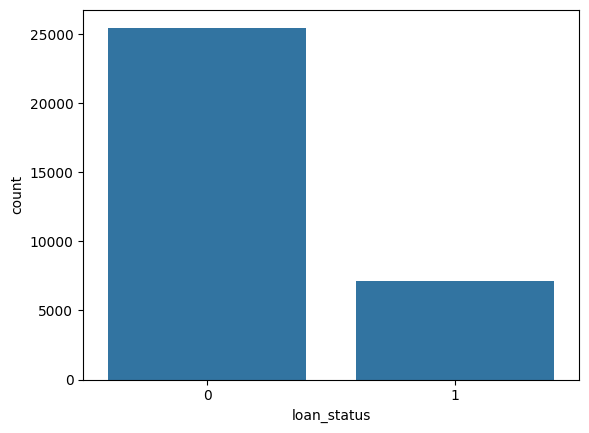

In [9]:
# Checking the target column is it imbalanced or not
sns.countplot(x = df['loan_status'])

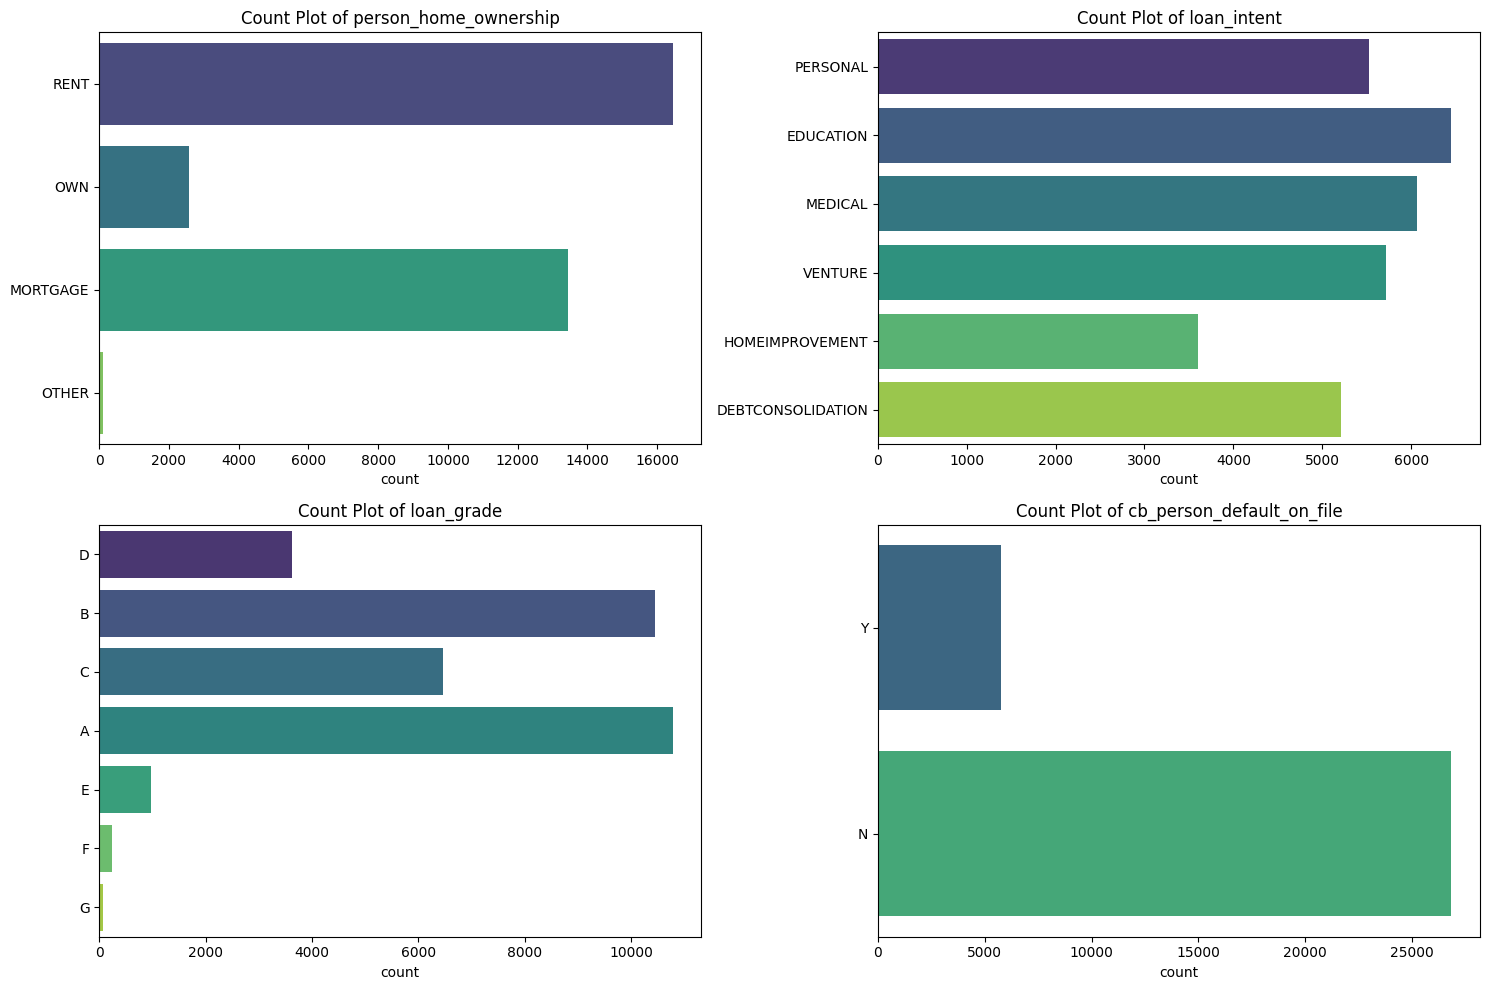

In [10]:
# Plot count plots for categorical columns (excluding target column if it's categorical)
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 2
n_rows = (len(categorical_cols) - 1) // n_cols + 1

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=df[col], palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [11]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

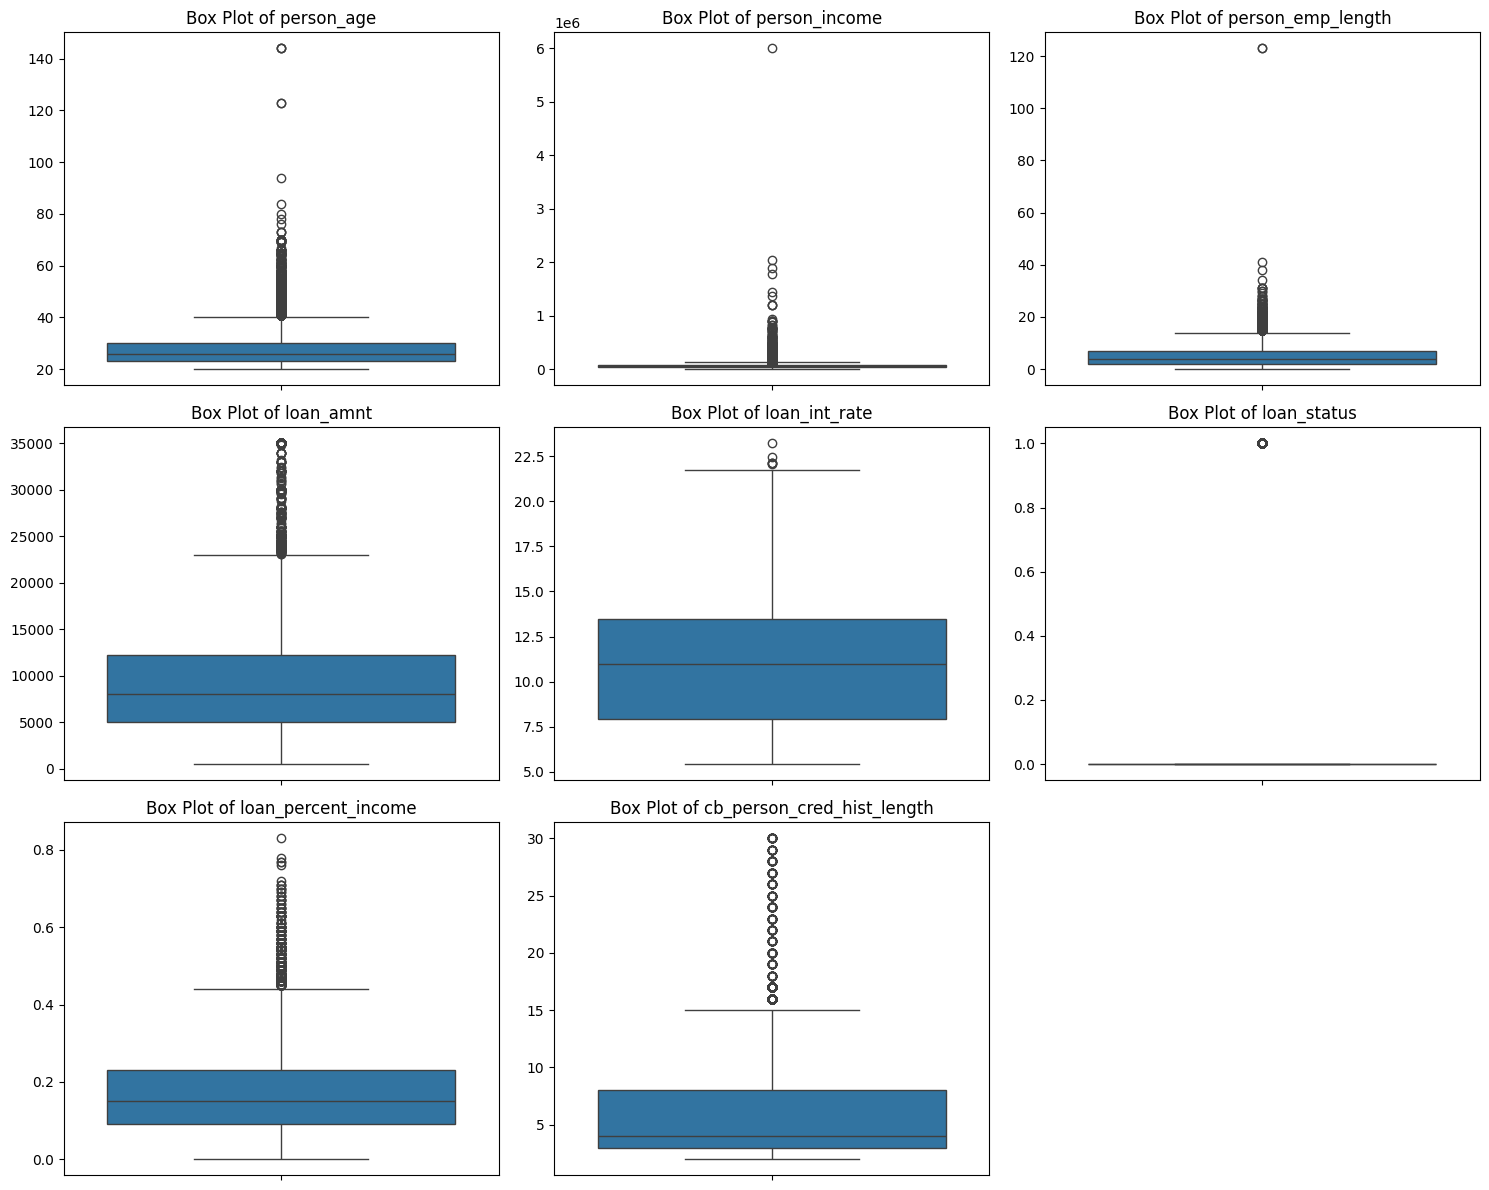

In [12]:
# Plot box plots for the numerical columns to identify outliers
num_cols = list(numerical_cols)
n_cols = 3
n_rows = (len(num_cols) - 1) // n_cols + 1

plt.figure(figsize=(15, 4 * n_rows))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

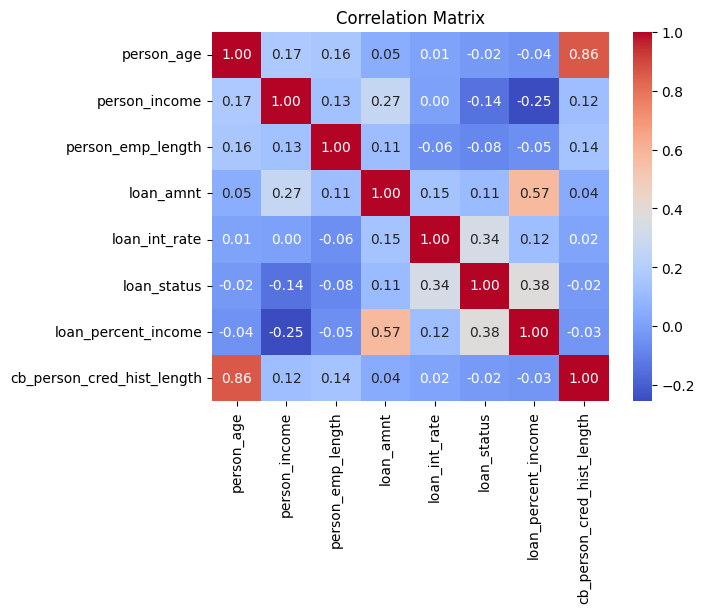

In [13]:
# Checking the correlation between columns
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

##3. Data Validation & Outliers Handling

In [14]:
# First create a copy of the original dataframe
df_copy = df.copy()

print(f'Rows count of the original dataframe: {df.shape[0]}')

df_copy.drop_duplicates(inplace=True)
print(f'Rows count of the dataframe after removing duplicates: {df_copy.shape[0]}')


Rows count of the original dataframe: 32581
Rows count of the dataframe after removing duplicates: 32416


In [15]:
# Remove the rows which have ages below 18 & above 100
df_copy = df_copy[(df_copy['person_age'] >= 18) & (df_copy['person_age'] <= 100)]
print(f'Rows count of the dataframe after removing ages below 18 & above 100')
df_copy.shape[0]

Rows count of the dataframe after removing ages below 18 & above 100


32411

In [16]:
# Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[(df_copy['person_emp_length'] <= df_copy['person_age']) & (df_copy['person_emp_length'] <= 60)]

##4. Feature Extraction & Train-Test Split

In [17]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

##5. Handle Class Imbalance

In [20]:
# find the class weight for XG Boost Classifier Model
a,b = np.bincount(y_train)
scale_weights = a/b

In [21]:
scale_weights

np.float64(3.6312213039485766)

##6. Data Preprocessing -> Pipelines & Column Transformer

#### 6.1 Preparing Pipeline for Logistic Regression

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline for Numerical Columns
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        # Pipeline for Categorical Columns
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

####6.2 Prepraing Pipeline for XG Boost Model

In [23]:
preprocessor_XG = ColumnTransformer(
    transformers=[
        # Pipeline for Numerical Columns
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),

        # Pipeline for Categorical Columns
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

##7. Evaluation Helper Function

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold= None ):
  y_pred_proba = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_proba > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrices
  accuracy = accuracy_score(y_test, y_pred)
  precision_s = precision_score(y_test, y_pred)
  recall_s = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)



  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f'Best Threshold : {best_threshold}')
  print(f'Accuracy Score: {accuracy:.2f}')
  print(f'Precision Score: {precision_s:.2f}')
  print(f'Recall Score: {recall_s:.2f}')
  print(f'F1 Score: {f1:.2f}')
  print()
  print(f'{model_name} Classification Report: ')
  print(class_report)

  # Plot the Confusion Matrix
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix for {model_name}')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.show()

  # Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_proba)
  plt.plot(recalls, precisions, label='Precision-Recall Curve')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision-Recall Curve')
  plt.legend()
  plt.show()

##8. Cross Validation

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1' : 'f1'}

In [33]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced' ,random_state=42))
])

In [34]:
# XG Boost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_XG),
    ('classifier', XGBClassifier(n_estimator = 300, max_depth = 5, learning_rate = 0.1,  scale_pos_weight=scale_weights, random_state=42))
])

In [35]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline), ('XG Boost', xgb_cv_pipeline)]:
  cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

  print(f'CV Results for {cv_name}')
  print(f'ROC AUC: {cv_results["test_roc_auc"].mean()}')
  print(f'Accuracy: {cv_results["test_accuracy"].mean()}')
  print(f'Precision: {cv_results["test_precision"].mean()}')
  print(f'Recall: {cv_results["test_recall"].mean()}')
  print(f'F1 Score: {cv_results["test_f1"].mean()}')
  print()

CV Results for Logistic Regression
ROC AUC: 0.8705112830525306
Accuracy: 0.8115949542892269
Precision: 0.5448226008889892
Recall: 0.7781450872359963
F1 Score: 0.6408013995933108

CV Results for XG Boost
ROC AUC: 0.9393848243386111
Accuracy: 0.9086724038455642
Precision: 0.7913354492271174
Recall: 0.7856749311294765
F1 Score: 0.7880291923045915



##9. Baseline Model for Logistic Regression

In [36]:
baseline_model = Pipeline(steps=[
  ('preprocessor', preprocessor_lr),
  ('classifier', LogisticRegression(class_weight='balanced'))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Accuracy Score: 0.82
Precision Score: 0.56
Recall Score: 0.79
F1 Score: 0.65

Logistic Regression Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



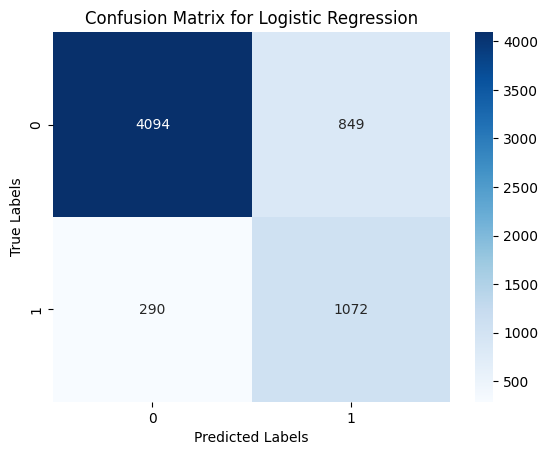

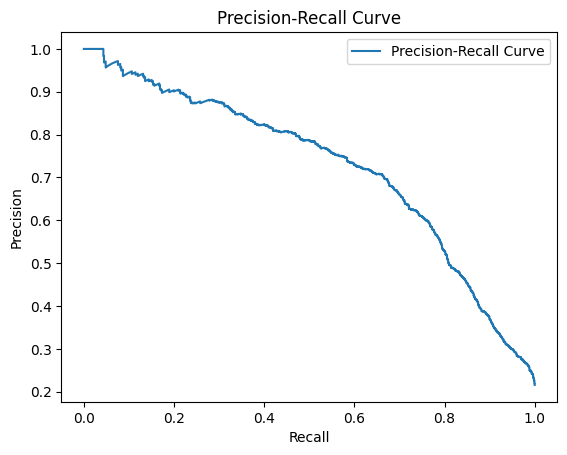

In [37]:
 # Evaluate the Logistic Regression model

 evaluate_model('Logistic Regression', baseline_model, X_test, y_test)


##10.  Baseline of XG Boost Model

In [38]:
xg_model = Pipeline(steps=[
    ('preprocessor', preprocessor_XG),
    ('classifier', XGBClassifier(learning_rate = 0.1, scale_pos_weight = scale_weights, random_state=42))
])

xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy Score: 0.92
Precision Score: 0.82
Recall Score: 0.79
F1 Score: 0.81

XG Boost Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



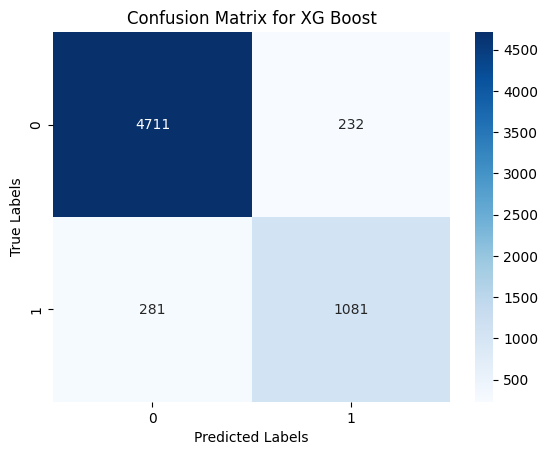

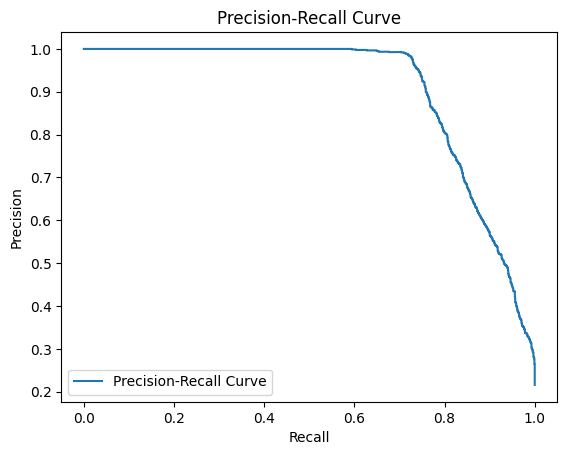

In [39]:
# Evaluate the XG Boost Model
evaluate_model('XG Boost', xg_model, X_test, y_test)

##11. Hyperparameter Parameter Tuning

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
param_grid = {
    'classifier__n_estimators': randint(150, 600),
    'classifier__max_depth': randint(3,9),
    'classifier__learning_rate': uniform(0.01, 0.5),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__gamma': uniform(0, 5)
}

In [42]:
random_search = RandomizedSearchCV(
    estimator=xg_model,
    param_distributions=param_grid,
    n_iter=150,
    scoring='average_precision',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002384541F750>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000023844E7C2F0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002384541F390>},
                   scoring='average_precision', verbose=1)

Best Threshold : 0.9996131062507629
Accuracy Score: 0.78
Precision Score: 0.00
Recall Score: 0.00
F1 Score: 0.00

XG Boost Classification Report: 
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



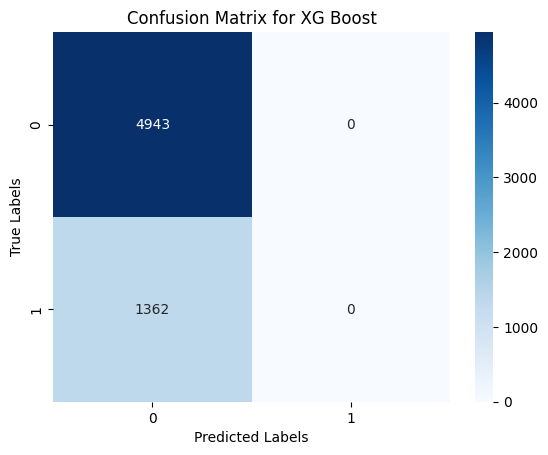

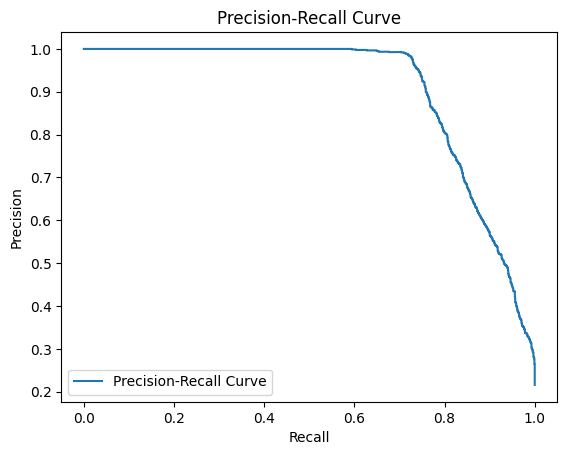

In [43]:
# Get the prob of class from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1[:-1])]

evaluate_model('XG Boost', xg_model, X_test, y_test, best_threshold)

##12. Probility Calibration

In [44]:
#1. Calibrated XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_xg_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_xg_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.05765689120172312),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=8,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=504,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [45]:
# Get Probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_xg_model.predict_proba(X_test)[:, 1]

In [46]:
# Create Calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

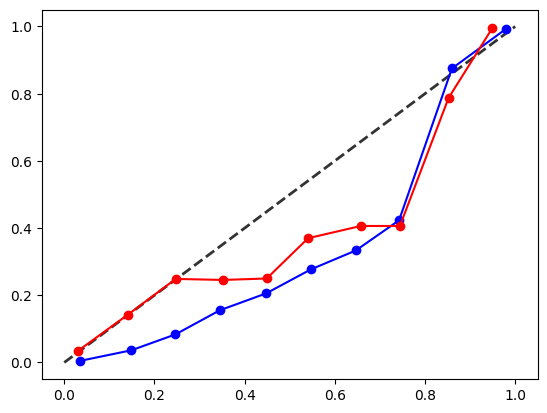

In [47]:
# Plot

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', label='Perfect Calibration', alpha=.8)

plt.plot(
    predicted_uncal, actual_uncal, marker='o', linestyle='-',
    color='blue', label='Uncalibrated'
)

plt.plot(
    predicted_cal, actual_cal, marker='o', linestyle='-',
    color='red', label='Calibrated'
)

## 13. SHAP Interpretation - Global & Local

In [48]:
import shap

In [49]:
# Get the trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [50]:
# Transform the X_test using the same preprocessing used for training
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [51]:
# get feature names after one-hot encoding , so plots are became readable
feature_name = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [52]:
# Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_name)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [53]:
# Create SHAP explainer built for tree based model
explainer = shap.TreeExplainer(xgb_classifier)

In [54]:
# Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]],
      shape=(6305, 26), dtype=float32)

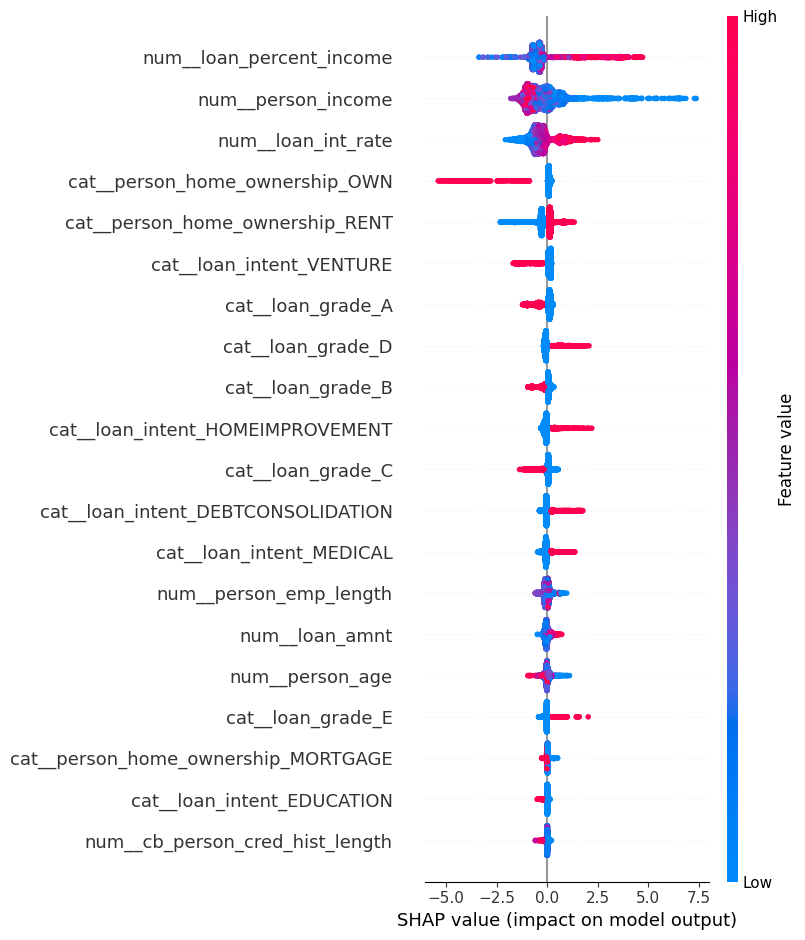

In [55]:
# Check the Global Explanation
shap.summary_plot(shap_values, X_test_df)

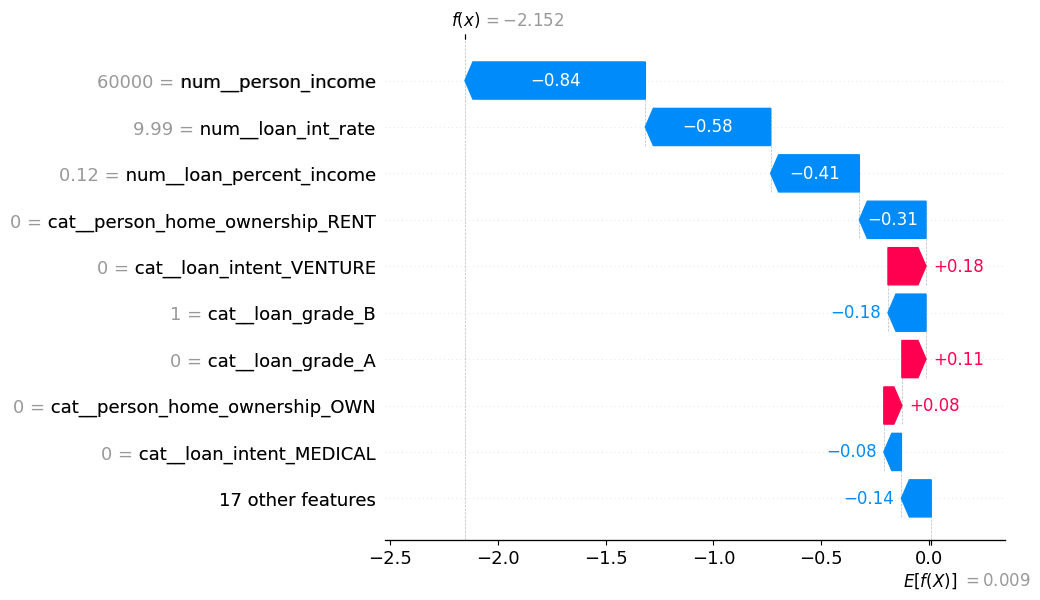

In [56]:
# Check the Local Explanation
# pick one row to explain

row_index = 5

# Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_name
    )
)

##14. Analyzing False Positives & False Negatives

In [57]:
y_pred = random_search.predict(X_test)

In [58]:
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [59]:
false_positives = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]
false_negatives = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [60]:
print(f'False Positives: {len(false_positives)}')
print(f'False Negatives: {len(false_negatives)}')

False Positives: 198
False Negatives: 274


##15. Save the Model

In [61]:
# We save the best model
import joblib

joblib.dump(calibrated_xg_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [62]:
# Now find the best threshold using the best model

# Get the probabilities from the Calibrated model
calibrated_proba = calibrated_xg_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f'Best Threshold: {best_threshold}')

Best Threshold: 0.5426102739552895


In [63]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']